# Main idea
An audio file format that stores audio using fourier transforms to decompose the audio into its various signals and then storing the properties of the waves.

# Steps to convert (from a wav file):
- Splits the audio into chunks (to make calculations faster)\
- Calculates the the fourier transform of each chunks
- Get each freqency from each wave from the chunk
- Write it to a file

# To reconstruct
- Sum up the waves given their frequencies
- Do an inverse fourier transform

In [54]:
# Fourier transform basic example
%pip install numpy matplotlib sympy
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

# https://stackoverflow.com/questions/4225432/how-to-compute-frequency-of-data-using-fft
SAMPLING_RATE = 999999
x_values = np.linspace(0, 1, SAMPLING_RATE)
AMOUNT_OF_SAMPLES = len(x_values)
sin_y_values = np.sin(x_values * 2 * np.pi * 30)
transformed_y_values = np.fft.fft(sin_y_values)
n0 = x_values[list(transformed_y_values).index(max(transformed_y_values))]
print(n0)
hertz = SAMPLING_RATE * n0

hertz /= AMOUNT_OF_SAMPLES
print(hertz)
print(hertz*10**np.ceil(np.log10(SAMPLING_RATE)))# 30.garbage the it gets closer and closer to the actual frequency the more samples there are


c:\Users\jalau\fourierTest\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.
3.0000060000119996e-05
3.0000060000119996e-05
30.000060000119994


The wave in this example: $\sin(2\cdot\pi\cdot10x)+\sin(2\cdot\pi\cdot15x)+\sin(2\cdot\pi\cdot20x)+\sin(2\cdot\pi\cdot25x)$

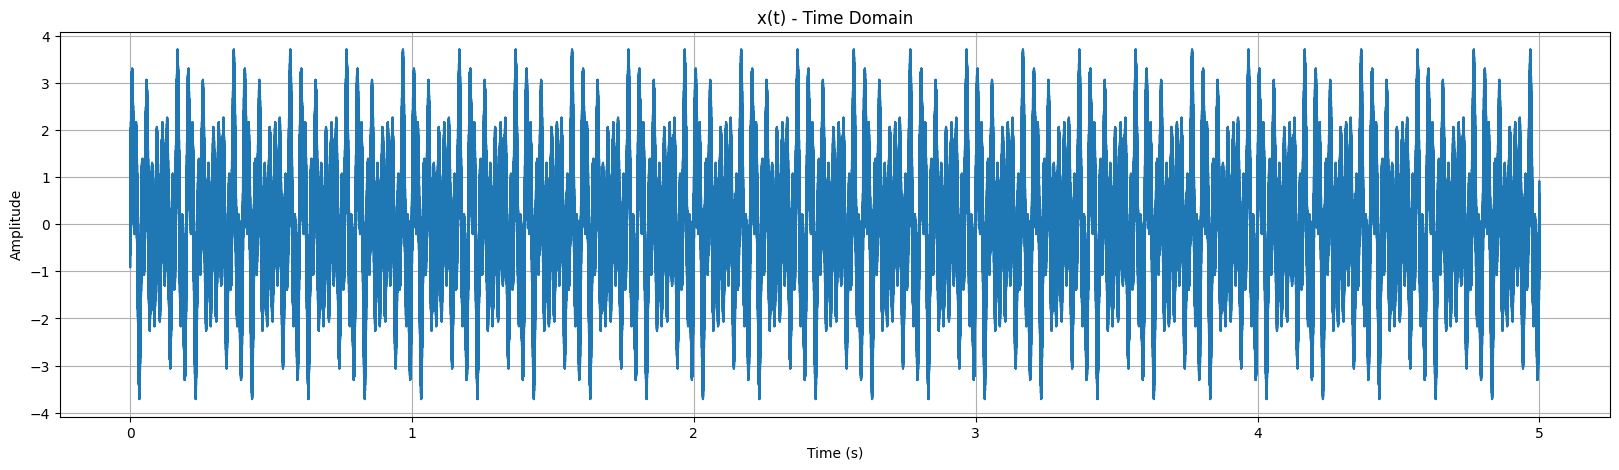

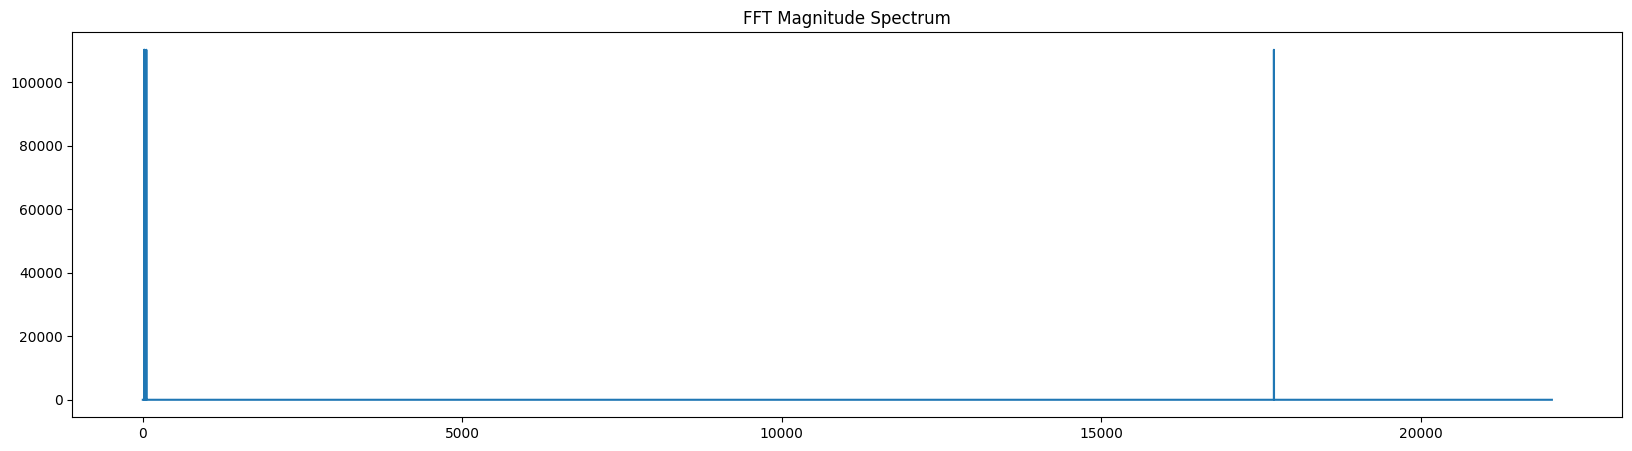

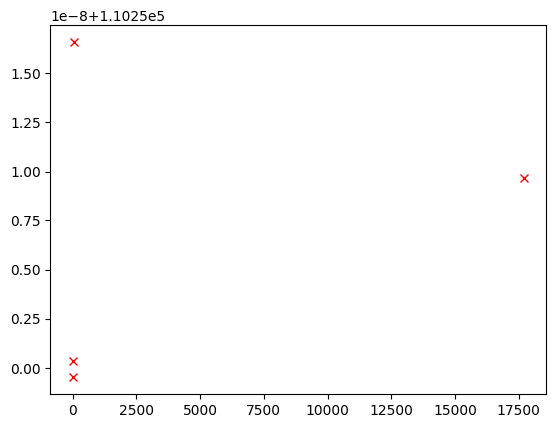

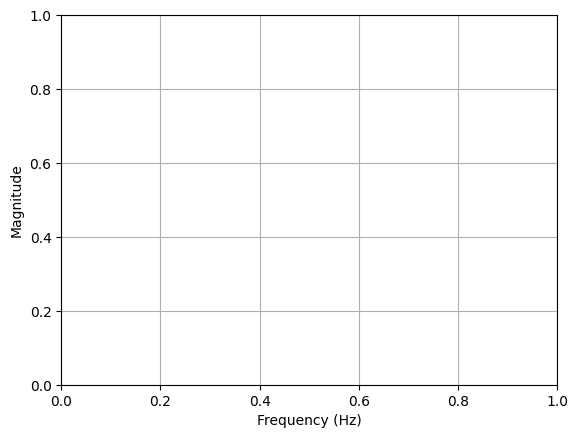

Detected frequencies:
20.0 Hz
25.0 Hz
55.0 Hz
17700.0 Hz


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def x(t):
    return (np.sin(2 * np.pi * 55 * t) +
            np.sin(2 * np.pi * 150000 * t) +
            np.sin(2 * np.pi * 20 * t) +
            np.sin(2 * np.pi * 25 * t))
SAMPLING_RATE = 44100
DURATION = 5
SAMPLES = SAMPLING_RATE * DURATION
t = np.linspace(0, DURATION, SAMPLES, endpoint=False)
y = x(t)
fft_result = np.fft.fft(y)
fft_magnitude = np.abs(fft_result[:SAMPLES // 2])
frequencies = np.fft.fftfreq(SAMPLES, d=1/SAMPLING_RATE)[:SAMPLES // 2]
peaks, props = find_peaks(fft_magnitude, height=10000) 
plt.figure(figsize=(20, 5))
plt.title("x(t) - Time Domain")
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()
plt.figure(figsize=(20, 5))
plt.title("FFT Magnitude Spectrum")
plt.plot(frequencies, fft_magnitude)
plt.show()
plt.plot(frequencies[peaks], fft_magnitude[peaks], "rx")
plt.show()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()
print("Detected frequencies:")
for p in peaks:
    print(f"{frequencies[p]} Hz")

C:\Users\jalau\AppData\Local\Temp\ipykernel_30496\3184260849.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  SAMPLE_RATE, data = wavfile.read("./input/BadApple.wav")


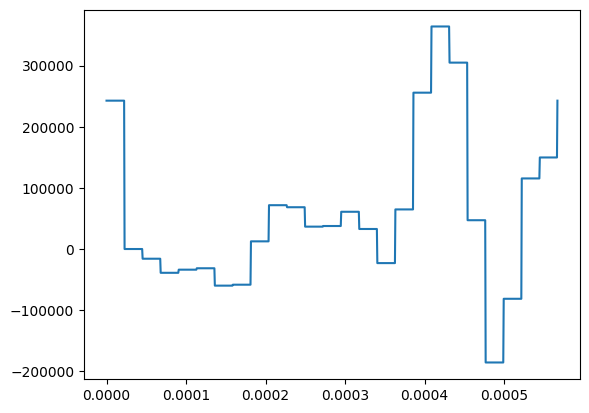

[3 9]
Freqs: [np.float64(5292.0), np.float64(15876.0)]


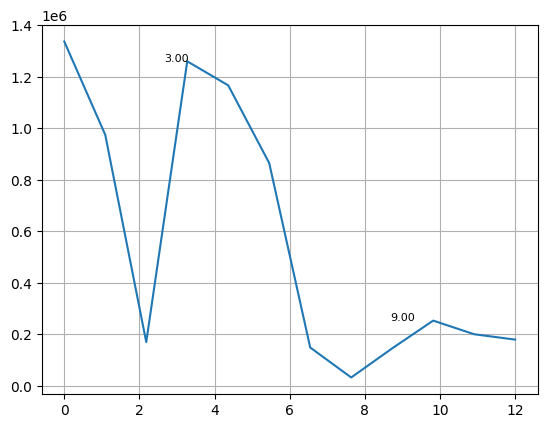

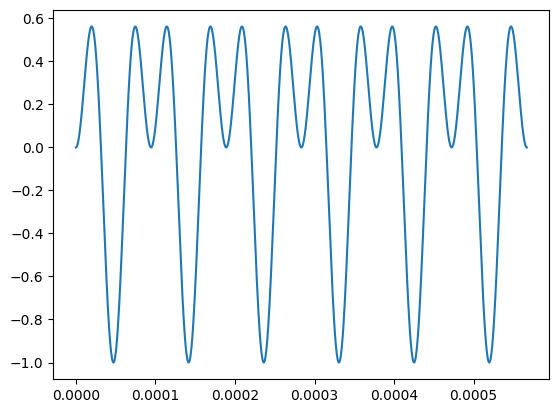

In [96]:
# On an actual (simple) audio signal
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, find_peaks_cwt

SAMPLE_RATE, data = wavfile.read("./input/BadApple.wav")
data = data[:, 1]

chunks = [data[i:(i + 25)] for i in range(0, len(data), 25)]
data = chunks[0]

DURATION = len(data) / SAMPLE_RATE
SAMPLES = len(data)

times = np.linspace(0, DURATION, 1000)

signal_values = [data[int(time * SAMPLE_RATE)-1] for time in times]
frequencies = np.fft.fftfreq(data.size, d=1/SAMPLE_RATE)[:data.size // 2]



plt.plot(times, signal_values)

plt.show()

fft = np.fft.fft(data)
fft = fft[:len(fft)//2]

fft = abs(fft)
peaks, props = find_peaks(fft )

print(peaks)
plt.plot(np.linspace(0, len(fft), len(fft)), fft)
plt.grid(True)
result = []
for peak in peaks:
    plt.text(peak, fft[peak], f'{peak:.2f}', ha='center', fontsize=8)
    result.append(frequencies[peak])
print(f"Freqs: {result}")

def func(x):
    return np.sin(x * 2 * np.pi * result[0]) * np.sin(x * 2 * np.pi * result[1]) 

plt.show()

plt.plot(times, func(times))
plt.show()






